In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive (1).zip to archive (1).zip


In [2]:
import zipfile
import os

zip_file_name = list(uploaded.keys())[0]

extract_path = "/content/emotion_data"

In [4]:
with zipfile.ZipFile(zip_file_name,'r') as zip_ref:
  zip_ref.extractall(extract_path)

In [5]:
train_dir = "/content/emotion_data/train"
test_dir = "/content/emotion_data/test"

In [9]:
!pip install -q tensorflow opencv-python matplotlib

In [10]:
import os

In [31]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import cv2
from tensorflow.keras.preprocessing import image

In [12]:
img_height = 48
img_width = 48
batch_size = 32
epochs = 10

In [13]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    shuffle=True
)

Found 28709 files belonging to 7 classes.


In [14]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(48, 48),
    batch_size=32,
    color_mode="grayscale",
    shuffle=False
)

Found 7178 files belonging to 7 classes.


In [15]:
class_names = train_dataset.class_names
num_classes = len(class_names)

print("Classes:", class_names)

Classes: ['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


In [16]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(48, 48, 1)),
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation='softmax')


])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 73ms/step - accuracy: 0.3181 - loss: 1.7020 - val_accuracy: 0.4012 - val_loss: 1.5618
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 67s 75ms/step - accuracy: 0.4375 - loss: 1.4603 - val_accuracy: 0.4741 - val_loss: 1.3552
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 66s 74ms/step - accuracy: 0.4858 - loss: 1.3473 - val_accuracy: 0.4987 - val_loss: 1.3048
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 64s 71ms/step - accuracy: 0.5174 - loss: 1.2709 - val_accuracy: 0.5160 - val_loss: 1.2631
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 63s 70ms/step - accuracy: 0.5415 - loss: 1.2081 - val_accuracy: 0.5294 - val_loss: 1.2319
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 66s 74ms/step - accuracy: 0.5611 - loss: 1.1581 - val_accuracy: 0.5359 - val_loss: 1.2044
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 69s 77ms/step - accuracy: 0.5818 - loss: 1.1150 - val_accuracy: 0.5393 - val_loss: 1.2093
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 76s 70ms/step - accuracy: 0.5963 - loss: 1.0721 - 

In [19]:
loss, acc = model.evaluate(test_dataset)
print("Accuracy:", acc)

225/225 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.5580 - loss: 1.1992
Accuracy: 0.5579548478126526


In [20]:
num_images= 10

plt.figure(figsize=(15,15))

results = []

<Figure size 1500x1500 with 0 Axes>

In [23]:
import random
for i in range(num_images):
  actual_emotion = random.choice(class_names)
  class_folder =os.path.join(test_dir, actual_emotion)

In [25]:
image_name = random.choice(os.listdir(class_folder))
img_path = os.path.join(class_folder, image_name)

In [29]:
img = image.load_img(img_path, color_mode="grayscale", target_size=(48, 48))
img_array = image.img_to_array(img)

In [32]:
img_input = np.expand_dims(img_array, axis=0)
prediction = model.predict(img_input, verbose=0)
predicted_emotion = class_names[np.argmax(prediction)]

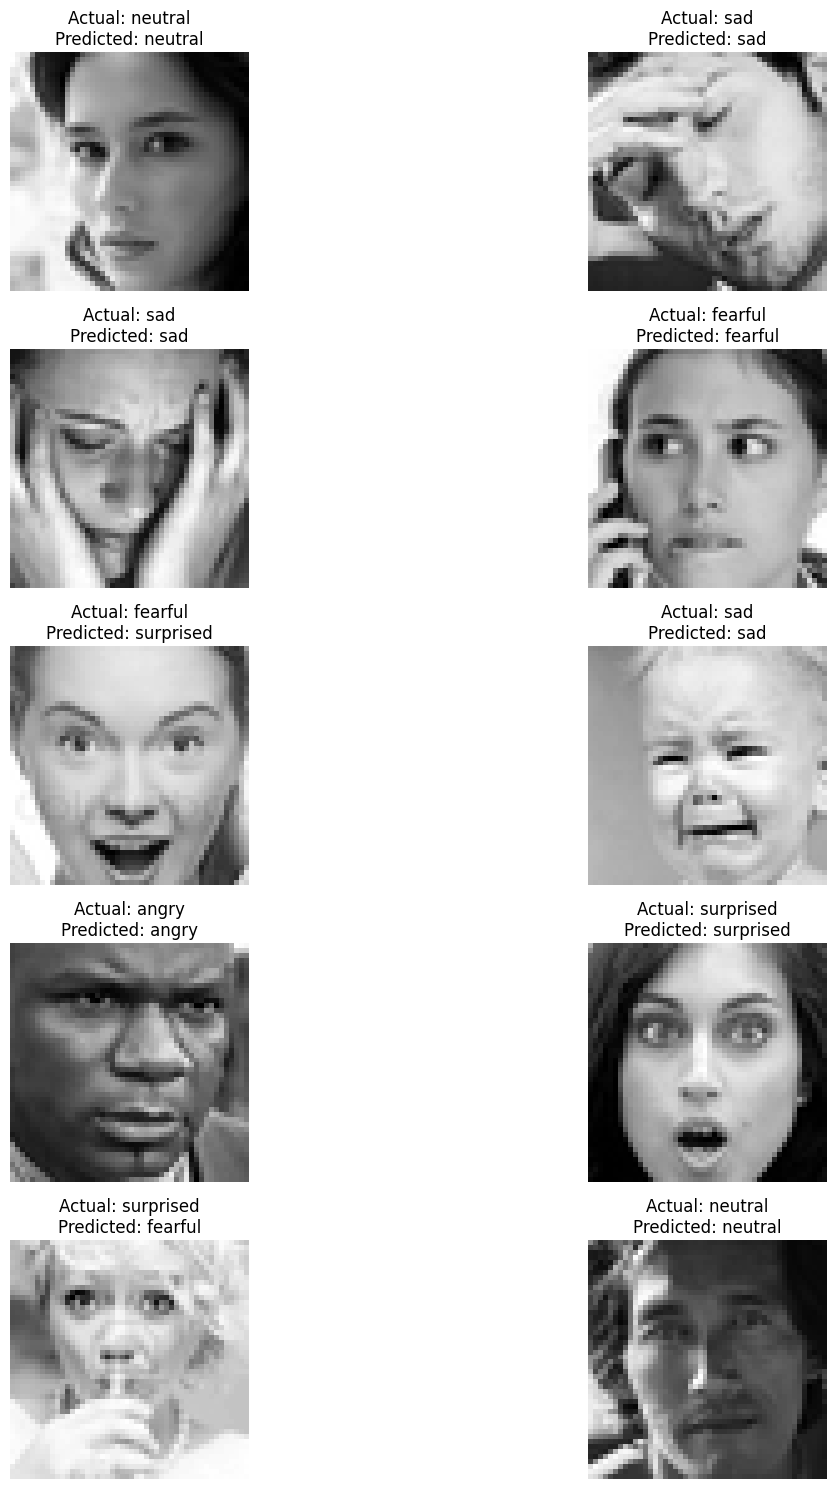

Prediction Results:
Image: im637.png, Actual: neutral, Predicted: neutral
Image: im1126.png, Actual: sad, Predicted: sad
Image: im720.png, Actual: sad, Predicted: sad
Image: im317.png, Actual: fearful, Predicted: fearful
Image: im388.png, Actual: fearful, Predicted: surprised
Image: im22.png, Actual: sad, Predicted: sad
Image: im771.png, Actual: angry, Predicted: angry
Image: im61.png, Actual: surprised, Predicted: surprised
Image: im273.png, Actual: surprised, Predicted: fearful
Image: im351.png, Actual: neutral, Predicted: neutral


In [35]:
plt.figure(figsize=(15, 15))
results = []

for i in range(num_images):
    actual_emotion = random.choice(class_names)
    class_folder = os.path.join(test_dir, actual_emotion)
    image_name = random.choice(os.listdir(class_folder))
    img_path = os.path.join(class_folder, image_name)

    img = image.load_img(img_path, color_mode="grayscale", target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_input = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_input, verbose=0)
    predicted_emotion = class_names[np++-prediction)]

    results.append({
        "image_path": img_path,
        "actual_emotion": actual_emotion,
        "predicted_emotion": predicted_emotion
    })

    # Use a 5x2 grid for 10 images
    plt.subplot(5, 2, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {actual_emotion}\nPredicted: {predicted_emotion}")
    plt.axis('off')

plt.tight_layout()
plt.show()

print("Prediction Results:")
for res in results:
    print(f"Image: {os.path.basename(res['image_path'])}, Actual: {res['actual_emotion']}, Predicted: {res['predicted_emotion']}")

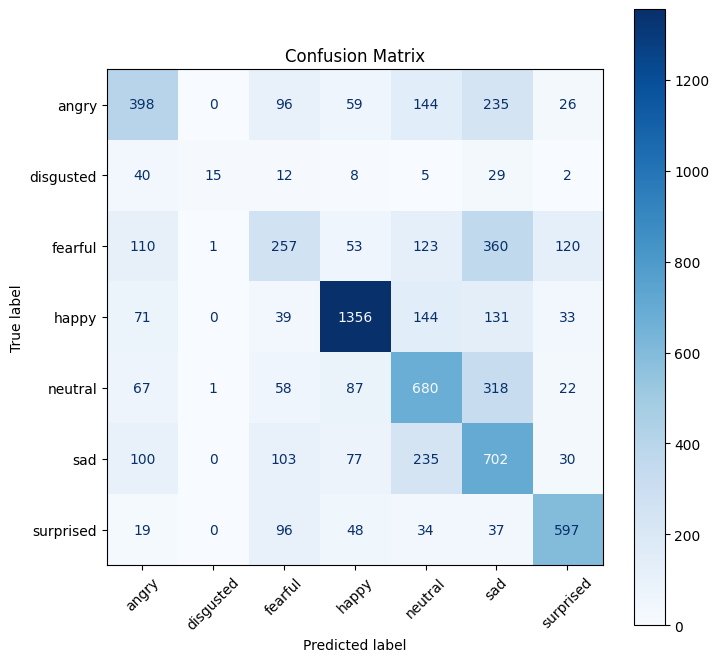

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()